In [21]:
import pandas as pd

df = pd.read_csv("../dataset/Food_Data_Original.csv")

In [22]:
df.head()

,food_item,energy_kcal,carbs,protein_g,fat_g,free_sugar_g,fibre_g,cholesterol_mg,calcium_mg
0,Butternaan,300.0,50.0,7.0,10.0,2.0,2.0,15.0,50.0
1,Cupcake,200.0,30.0,2.0,8.0,20.0,0.5,20.0,20.0
2,Donuts,250.0,30.0,3.0,12.0,10.0,1.0,20.0,20.0
3,French Fries,312.0,41.0,3.4,15.0,0.3,3.8,0.0,20.0
4,Garlic Bread,200.0,25.0,4.0,10.0,1.0,1.0,10.0,30.0


In [23]:
df["health_risk_score"] = (
    df["free_sugar_g"] * 0.4 +
    df["fat_g"] * 0.3 +
    (df["cholesterol_mg"] / 10) * 0.2 -
    df["fibre_g"] * 0.1
)

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,100))

df["health_risk_score"] = scaler.fit_transform(
    df[["health_risk_score"]]
)

In [25]:
df.sort_values("health_risk_score", ascending=True)

,food_item,energy_kcal,carbs,protein_g,fat_g,free_sugar_g,fibre_g,cholesterol_mg,calcium_mg,health_risk_score
694,Gooseberry chutney (Amla chutney),43.02,8.83,1.44,0.62,0.06,4.58,0.00,46.40,0.000000
697,Gun powder chutney,312.34,47.65,21.55,2.67,1.16,13.95,0.00,68.87,0.311923
851,Pickled mustard greens,13.12,1.05,1.51,0.22,0.02,1.70,0.00,81.44,0.401800
144,Idli,137.54,28.18,4.64,0.33,0.28,2.31,0.00,8.00,0.602699
116,Boiled rice (Uble chawal),117.19,25.72,2.60,0.18,0.22,1.25,0.00,2.70,0.700506
...,...,...,...,...,...,...,...,...,...,...
730,Chocolate glace icing,436.29,62.43,3.22,20.80,59.88,0.00,44.49,26.75,82.817779
732,Chocolate butter icing,469.59,61.72,3.21,24.77,59.82,0.00,54.90,31.87,86.453008
965,Glace icing,323.51,86.31,0.01,0.01,85.35,0.00,0.00,1.95,90.909812
966,Royal icing,332.58,86.53,1.74,0.02,85.57,0.00,0.00,2.87,91.150363


<Axes: >

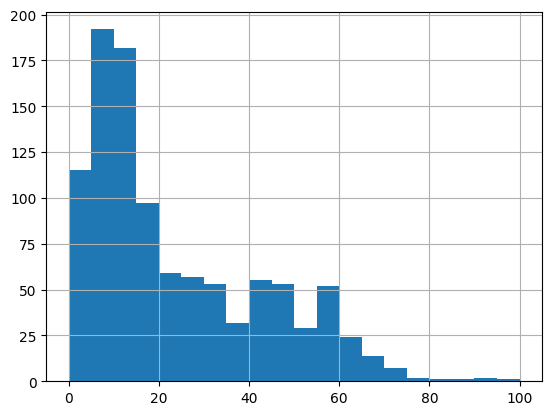

In [26]:
df["health_risk_score"].hist(bins=20)

In [30]:
from sklearn.preprocessing import StandardScaler

cols = [
    "protein_g",
    "fibre_g",
    "calcium_mg",
    "free_sugar_g",
    "fat_g"
]

scaled = StandardScaler().fit_transform(df[cols])

scaled_df = pd.DataFrame(
    scaled,
    columns=cols
)

df["nutrition_density"] = (
    scaled_df["protein_g"] +
    scaled_df["fibre_g"] +
    scaled_df["calcium_mg"]
    -
    scaled_df["free_sugar_g"]
    -
    scaled_df["fat_g"]
)

In [31]:
df["nutrition_density"] = MinMaxScaler(
    feature_range=(0,100)
).fit_transform(
    df[["nutrition_density"]]
)

In [32]:
df['nutrition_density'].describe()

count    1028.000000
mean       26.939480
std         8.991501
min         0.000000
25%        21.922167
50%        26.949990
75%        31.704542
max       100.000000
Name: nutrition_density, dtype: float64

In [33]:
df.columns

Index(['food_item', 'energy_kcal', 'carbs', 'protein_g', 'fat_g',
       'free_sugar_g', 'fibre_g', 'cholesterol_mg', 'calcium_mg',
       'health_risk_score', 'nutrition_density'],
      dtype='object')

In [34]:
#Connect to MySQL\
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3306/food_health_analysis"
)

connection = engine.connect()

print("Connected successfully!")

Connected successfully!


In [35]:
df.to_sql(
    name="nutrition",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
